# 5. Error Analysis and Limitations

**Research question.** Where does the system fail, why, and does it generalise beyond the training distribution?

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
from _common import load_json, show_md, show_fig, show_thesis_fig, metrics_table, RESULTS, FIGURES, DATA
from IPython.display import display
import pandas as pd
pd.set_option('display.max_colwidth', 120)

## 5.1 Error characterisation

Breakdown by class, comment length, negation, question form, and prediction confidence, plus the most confident *wrong* predictions. Source: `backend/results/error_characterization.md`.

In [2]:
show_md('error_characterization.md')

# Error Characterization (LogReg baseline)

Model: `model.sav`  |  Test set: `test.csv`  |  n = 165,110  |  overall accuracy = **0.6946**

> This file complements `error_analysis.md` (which shows individual high-confidence misclassifications). It slices the same errors by **text properties** (length, negation, question-like) so that the thesis Limitations section can point to concrete, quantified failure modes instead of isolated examples.

## Per-class performance

| Class | n | Accuracy | Recall | Precision |
|---|---:|---:|---:|---:|
| Negative | 59,614 | 0.7242 | 0.7242 | 0.6914 |
| Neutral | 50,540 | 0.6232 | 0.6232 | 0.6172 |
| Positive | 54,956 | 0.7283 | 0.7283 | 0.7751 |

## Accuracy by text length

| Length bucket | n | Accuracy |
|---|---:|---:|
| very_short (<=5 tok) | 15,781 | 0.7335 |
| short (6-15) | 73,083 | 0.6976 |
| medium (16-40) | 59,044 | 0.6872 |
| long (41+) | 17,202 | 0.6717 |

## Effect of negation markers

| Slice | n | Accuracy |
|---|---:|---:|
| with_negation | 46,791 | 0.6567 |
| without_negation | 118,319 | 0.7096 |

**Δ (with - without negation): -0.0529.** A negative delta indicates negation tokens make classification harder, which supports the choice in `src/preprocessing/classical.py` to keep negators in the stopword list and run negation tagging.

## Question-like vs statement-like

| Slice | n | Accuracy |
|---|---:|---:|
| question_like | 16,176 | 0.7264 |
| statement_like | 148,934 | 0.6912 |

## Confidence distribution for correct vs wrong predictions

| Outcome | Mean confidence | Std |
|---|---:|---:|
| Correct | 0.7436 | 0.1752 |
| Wrong   | 0.5933  | 0.1431 |

Confidence gap (correct − wrong) = **+0.1503**. A small gap means the model is 'confidently wrong' too often — exactly the calibration weakness the neuro-fuzzy gate targets.

## Most common confusion pairs

| True → Pred | Count | % of errors |
|---|---:|---:|
| Neutral → Negative | 12,120 | 24.0% |
| Negative → Neutral | 11,755 | 23.3% |
| Positive → Neutral | 7,782 | 15.4% |
| Positive → Negative | 7,151 | 14.2% |
| Neutral → Positive | 6,925 | 13.7% |
| Negative → Positive | 4,687 | 9.3% |

## Most confidently-wrong examples

| # | True | Pred | Conf | Len | Neg? | Text (first 200 chars) |
|---:|---|---|---:|---|---|---|
| 1 | Neutral | Positive | 0.999 | very_short (<=5 tok) | no | tera thank you |
| 2 | Neutral | Positive | 0.999 | very_short (<=5 tok) | no | thank you carryminati |
| 3 | Neutral | Positive | 0.999 | very_short (<=5 tok) | no | love kaitlan collins red heart |
| 4 | Neutral | Positive | 0.999 | medium (16-40) | no | heartfelt thanks to amazing ai for rescuingsaving the digital cheetah her adorable cute baby cheetahs are spectacularly precious sight its beautifully heartwarming smiling face with hearts |
| 5 | Negative | Positive | 0.998 | very_short (<=5 tok) | no | great shes pilferer red heart |
| 6 | Neutral | Positive | 0.998 | short (6-15) | no | learned lot through telusuko thank you |
| 7 | Neutral | Positive | 0.997 | medium (16-40) | yes | god bless you mel cant wait for the resurrection movie was absolutely devastated when watched your first one the passion sat there and just cried the whole time thank you red heart |
| 8 | Positive | Negative | 0.997 | short (6-15) | no | what disgusting cover up by disgusting people |
| 9 | Neutral | Positive | 0.997 | short (6-15) | no | love this mr gibson red heart |
| 10 | Positive | Negative | 0.997 | medium (16-40) | no | ridiculous worried about being called racist while little girls being raped in the worst way ridiculous |
| 11 | Neutral | Positive | 0.997 | very_short (<=5 tok) | no | thank you truckers |
| 12 | Positive | Negative | 0.997 | short (6-15) | no | please americans just dump trump the past lying toxic propaganda pushing fool |
| 13 | Neutral | Positive | 0.996 | medium (16-40) | no | congratulations im so glad this channel is growing so well great to see channel get the recognition they deserve |
| 14 | Neutral | Negative | 0.996 | very_short (<=5 tok) | yes | ugh cant stand awkward silences |
| 15 | Neutral | Positive | 0.996 | medium (16-40) | no | laura you are the bomb this interview nearly broke my heart in transcendental way thank you mel for your service to truth bravo smiling face with sunglasses heart on fire |
| 16 | Negative | Positive | 0.996 | short (6-15) | no | thank you for helping this amazing ia you are the future |
| 17 | Neutral | Positive | 0.996 | short (6-15) | no | love this guy the best actor and filmmaker in the world god bless mel gibson |
| 18 | Negative | Positive | 0.996 | long (41+) | yes | whenever saw your videos lost my mind and get stuck just by thinking whether may have programming skills like you or not most of the time really get disappointed because as software engineering studen |
| 19 | Neutral | Positive | 0.996 | medium (16-40) | no | babymonster red heart im so happy yall stan them they are my fav red heart red heart |
| 20 | Neutral | Positive | 0.995 | medium (16-40) | no | sir wish could understand hindicoz see your videos very informative and miss alot of details wish could have translations thank you thank you |

## Thesis-ready takeaways

1. **Length matters.** Accuracy on *long (41+)* comments is 0.6717 vs 0.7335 on *very_short (<=5 tok)* — short comments lose information that TF-IDF needs to discriminate classes.
2. **Negation is a weak spot.** Accuracy changes by -0.0529 when a negation marker is present. This validates the thesis choice to include negation tagging in the classical preprocessing path.
3. **Dominant confusion pair: Neutral → Negative (24.0% of all errors).** Addressing this single confusion would deliver the biggest headline improvement.
4. **Confidence gap = +0.1503.** The model is only modestly more confident when it is right than when it is wrong, which is exactly why calibration (not accuracy) is the honest contribution of the CI layer.


In [3]:
err = load_json('error_characterization.json')
pd.DataFrame(err['top_confident_errors'])

,text,true,pred,confidence,length_bucket,has_negation
0,tera thank you,Neutral,Positive,0.998976,very_short (<=5 tok),False
1,thank you carryminati,Neutral,Positive,0.998976,very_short (<=5 tok),False
2,love kaitlan collins red heart,Neutral,Positive,0.998601,very_short (<=5 tok),False
3,heartfelt thanks to amazing ai for rescuingsaving the digital cheetah her adorable cute baby cheetahs are spectacula...,Neutral,Positive,0.998565,medium (16-40),False
4,great shes pilferer red heart,Negative,Positive,0.997966,very_short (<=5 tok),False
5,learned lot through telusuko thank you,Neutral,Positive,0.997711,short (6-15),False
6,god bless you mel cant wait for the resurrection movie was absolutely devastated when watched your first one the pas...,Neutral,Positive,0.997218,medium (16-40),True
7,what disgusting cover up by disgusting people,Positive,Negative,0.997139,short (6-15),False
8,love this mr gibson red heart,Neutral,Positive,0.996967,short (6-15),False
9,ridiculous worried about being called racist while little girls being raped in the worst way ridiculous,Positive,Negative,0.996863,medium (16-40),False


## 5.2 Why is the Neutral class hardest?

Source: `backend/results/neutral_analysis/neutral_analysis.md`.

In [4]:
show_md('neutral_analysis/neutral_analysis.md')

# Neutral-Class Weakness Analysis and Intervention

- Model: `logreg`
- Val/Test sample size: 8,000 / 8,000
- Intervention: scale Neutral probability by `alpha` before argmax
  (prior adjustment / threshold tuning; no retraining).
- `alpha` selected on validation, reported on held-out test.

## 1. Error-Direction Analysis (baseline, test split)

Of 2,450 true-Neutral comments, the baseline `logreg` model:

| Outcome | Count | Share |
|---------|------:|------:|
| Correct (Neutral) | 1,508 | 61.6% |
| Misread as Negative | 599 | 24.4% |
| Misread as Positive | 343 | 14.0% |

Neutral errors are split between both polar classes, i.e. the model
tends to over-commit short, low-signal comments to a polarity rather
than abstaining to Neutral. This motivates a Neutral-favouring prior.

## 2. Alpha Sweep (validation split)

| alpha | Macro-F1 | Neutral-F1 | Neutral-P | Neutral-R |
|------:|---------:|-----------:|----------:|----------:|
| 0.8 | 0.6847 | 0.5937 | 0.6428 | 0.5516 |
| 0.9 | 0.6892 | 0.6097 | 0.6279 | 0.5925 |
| 1.0 | 0.6887 | 0.6153 | 0.6090 | 0.6217 |
| 1.1 | 0.6881 | 0.6189 | 0.5941 | 0.6459 |
| 1.2 | 0.6906 | 0.6269 | 0.5842 | 0.6764 |
| 1.3 | 0.6920 | 0.6336 | 0.5755 | 0.7048 |
| 1.4 | 0.6912 | 0.6362 | 0.5645 | 0.7286 |
| 1.5 | 0.6893 | 0.6388 | 0.5570 | 0.7486 |
| 1.6 | 0.6872 | 0.6405 | 0.5496 | 0.7674 |  <-- selected
| 1.7 | 0.6841 | 0.6395 | 0.5425 | 0.7787 |
| 1.8 | 0.6812 | 0.6387 | 0.5356 | 0.7908 |
| 1.9 | 0.6755 | 0.6342 | 0.5258 | 0.7987 |
| 2.0 | 0.6714 | 0.6328 | 0.5185 | 0.8117 |

Selected `alpha = 1.6` (maximises validation Neutral-F1 subject
to macro-F1 dropping no more than 0.005).

## 3. Held-Out Test Result (baseline vs intervention)

| Metric | Baseline (alpha=1.0) | Intervention (alpha=1.6) | Delta |
|--------|---------------------:|-------------------------:|------:|
| Macro-F1 | 0.6922 | 0.6814 | -0.0108 |
| Neutral-F1 | 0.6175 | 0.6326 | +0.0151 |
| Neutral-Precision | 0.6196 | 0.5486 | — |
| Neutral-Recall | 0.6155 | 0.7469 | — |

## 4. Verdict

**Mixed result.** Neutral-F1 improved by +0.0151 but macro-F1
dropped by -0.0108, exceeding tolerance. The Neutral/macro trade-off
means the intervention is only justified when Neutral recall is the priority.

## 5. Recommendation

- The Neutral class is intrinsically hardest: it has the shortest comments
  (EDA: median 12 words vs 16/15) and the lowest inter-annotator separability.
- Threshold tuning is reported here as a transparent, training-free option.
- Stronger future remedies: class-weighted retraining, Neutral-vs-rest
  cascade classifier, or richer contextual features (encoder embeddings).



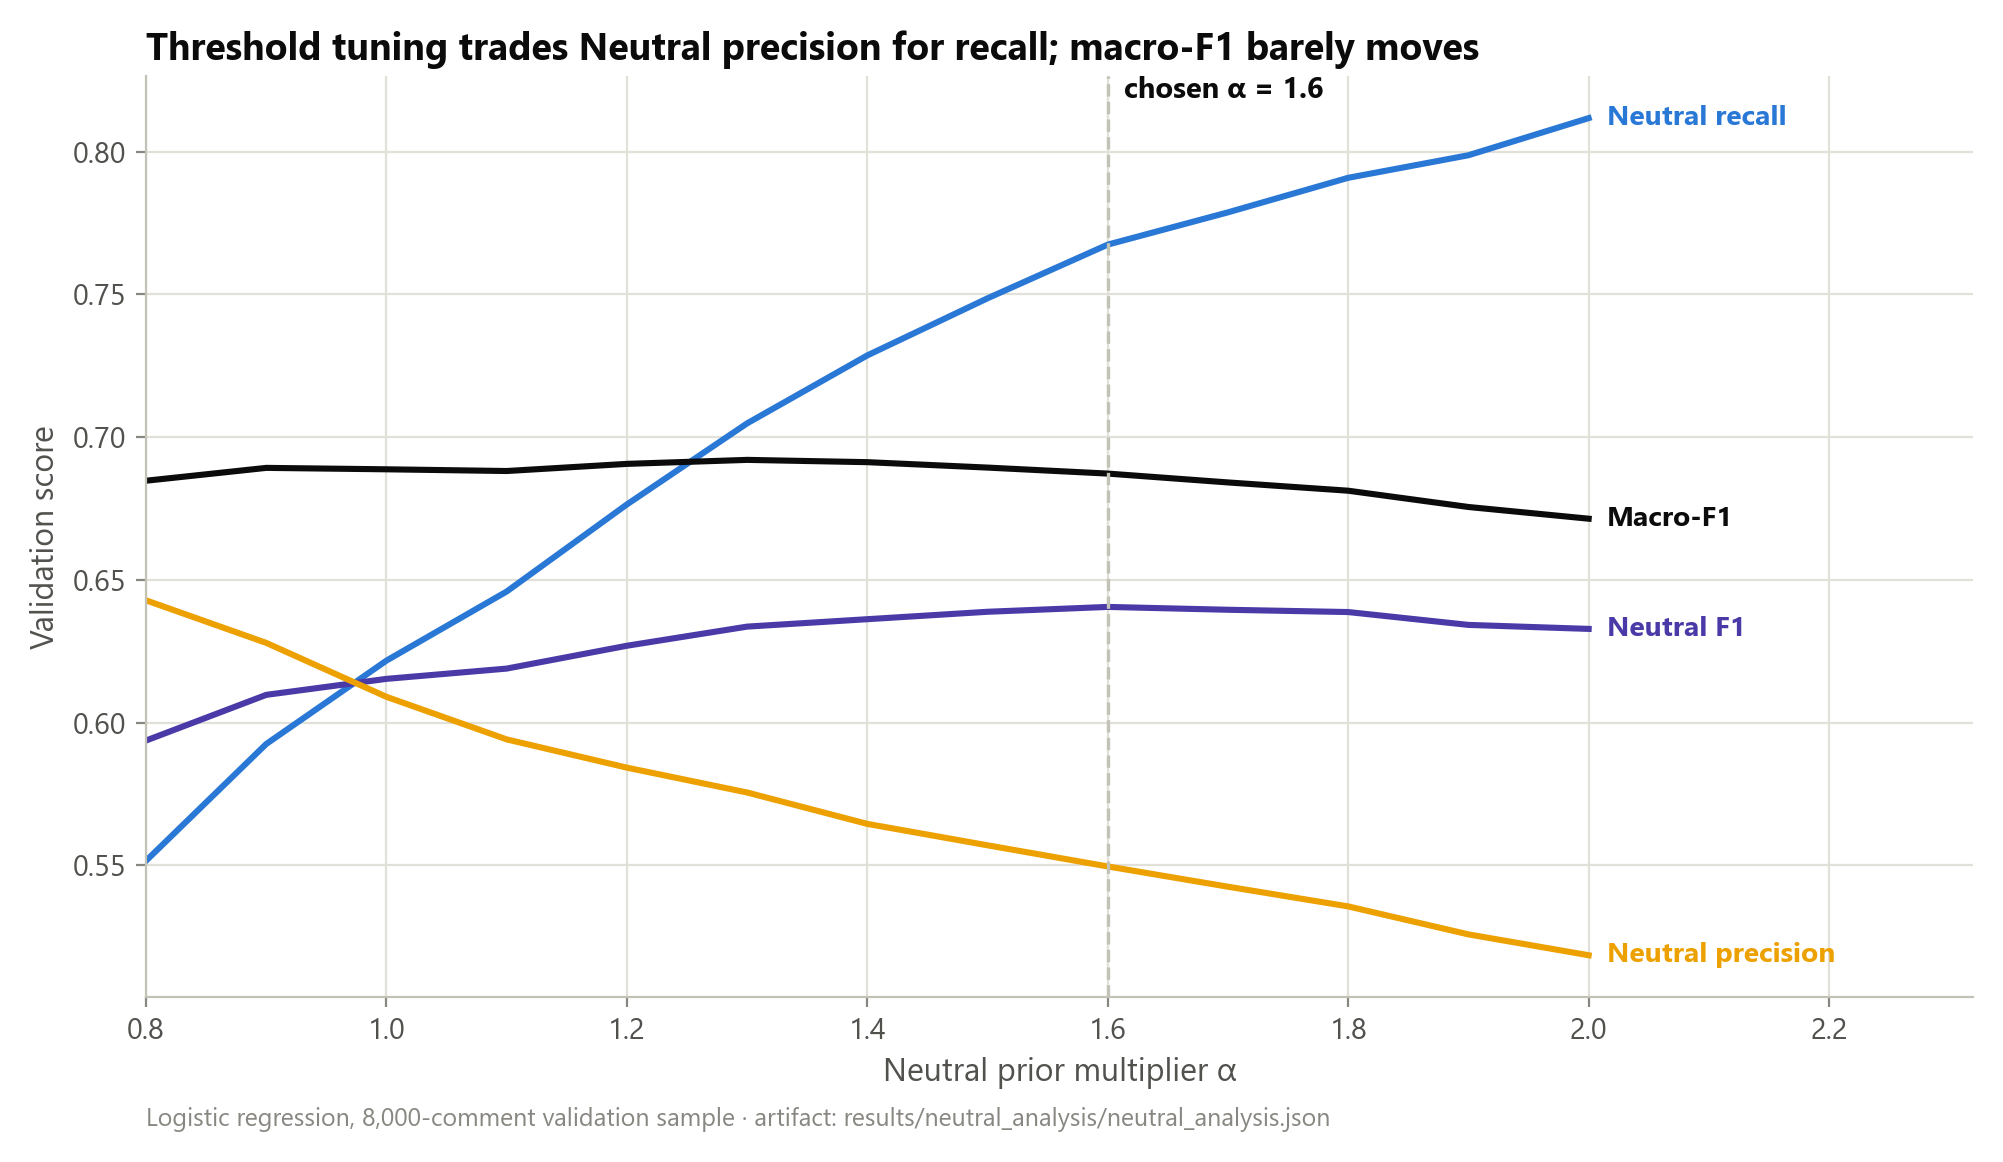

In [5]:
show_thesis_fig('fig_neutral_sweep.png')

## 5.3 Domain shift — does performance hold across video category and country?

Sources: `backend/results/domain_shift/category_domain_shift.md`, `backend/results/domain_shift/country_domain_shift.md`.

In [6]:
show_md('domain_shift/category_domain_shift.md')

# Domain-Shift / Robustness Slice Evaluation

- Created at: `2026-05-18T01:47:02Z`
- Dataset: `C:\Users\itsma\OneDrive\Documents\GitHub\Youtube_sentiment_analysis\backend\data\route_a_domain_10k\test.csv`
- Slice column: `CategoryID`
- Slice source: `metadata`
- Samples: `1641`

## Overall

| Model | Accuracy | Macro-F1 | Worst Slice | Worst Slice F1 | Spread |
| --- | ---: | ---: | --- | ---: | ---: |
| logreg | 0.736746 | 0.736832 | 24 | 0.616778 | 0.209862 |
| svm | 0.736137 | 0.735756 | 24 | 0.675920 | 0.138120 |
| tfidf | 0.678245 | 0.676433 | 24 | 0.604831 | 0.161669 |
| ensemble_nsga2 | 0.735527 | 0.735490 | 24 | 0.616778 | 0.209862 |
| meta_learner | 0.731261 | 0.732183 | 24 | 0.635317 | 0.190155 |

## logreg Slices

| Slice | Samples | Accuracy | Macro-F1 |
| --- | ---: | ---: | ---: |
| 24 | 85 | 0.635294 | 0.616778 |
| 20 | 43 | 0.651163 | 0.655961 |
| 25 | 499 | 0.697395 | 0.690608 |
| 17 | 144 | 0.694444 | 0.695188 |
| 1 | 32 | 0.718750 | 0.707741 |
| 28 | 77 | 0.727273 | 0.719577 |
| 26 | 135 | 0.740741 | 0.734680 |
| 22 | 44 | 0.795455 | 0.741486 |
| 2 | 65 | 0.784615 | 0.765762 |
| 27 | 437 | 0.796339 | 0.771699 |
| 15 | 80 | 0.825000 | 0.826640 |

## svm Slices

| Slice | Samples | Accuracy | Macro-F1 |
| --- | ---: | ---: | ---: |
| 24 | 85 | 0.682353 | 0.675920 |
| 20 | 43 | 0.674419 | 0.677469 |
| 25 | 499 | 0.687375 | 0.681768 |
| 17 | 144 | 0.687500 | 0.688110 |
| 1 | 32 | 0.718750 | 0.708354 |
| 22 | 44 | 0.795455 | 0.740669 |
| 26 | 135 | 0.755556 | 0.752699 |
| 2 | 65 | 0.784615 | 0.759339 |
| 28 | 77 | 0.766234 | 0.761303 |
| 27 | 437 | 0.787185 | 0.767564 |
| 15 | 80 | 0.812500 | 0.814040 |

## tfidf Slices

| Slice | Samples | Accuracy | Macro-F1 |
| --- | ---: | ---: | ---: |
| 24 | 85 | 0.623529 | 0.604831 |
| 25 | 499 | 0.637275 | 0.614687 |
| 17 | 144 | 0.638889 | 0.635281 |
| 26 | 135 | 0.674074 | 0.660796 |
| 27 | 437 | 0.709382 | 0.666188 |
| 28 | 77 | 0.714286 | 0.666344 |
| 1 | 32 | 0.687500 | 0.672649 |
| 2 | 65 | 0.753846 | 0.683810 |
| 20 | 43 | 0.697674 | 0.702160 |
| 15 | 80 | 0.712500 | 0.713963 |
| 22 | 44 | 0.818182 | 0.766500 |

## ensemble_nsga2 Slices

| Slice | Samples | Accuracy | Macro-F1 |
| --- | ---: | ---: | ---: |
| 24 | 85 | 0.635294 | 0.616778 |
| 1 | 32 | 0.687500 | 0.661616 |
| 20 | 43 | 0.674419 | 0.679029 |
| 17 | 144 | 0.687500 | 0.687861 |
| 25 | 499 | 0.697395 | 0.689136 |
| 26 | 135 | 0.733333 | 0.726422 |
| 28 | 77 | 0.740260 | 0.733976 |
| 22 | 44 | 0.795455 | 0.741486 |
| 2 | 65 | 0.784615 | 0.765762 |
| 27 | 437 | 0.794050 | 0.767587 |
| 15 | 80 | 0.825000 | 0.826640 |

## meta_learner Slices

| Slice | Samples | Accuracy | Macro-F1 |
| --- | ---: | ---: | ---: |
| 24 | 85 | 0.647059 | 0.635317 |
| 20 | 43 | 0.651163 | 0.657617 |
| 1 | 32 | 0.687500 | 0.662500 |
| 17 | 144 | 0.680556 | 0.682985 |
| 25 | 499 | 0.701403 | 0.694887 |
| 28 | 77 | 0.714286 | 0.711525 |
| 26 | 135 | 0.725926 | 0.720690 |
| 27 | 437 | 0.780320 | 0.749503 |
| 2 | 65 | 0.784615 | 0.767484 |
| 22 | 44 | 0.818182 | 0.779810 |
| 15 | 80 | 0.825000 | 0.825472 |

## Interpretation

This is a metadata-backed domain-slice evaluation.


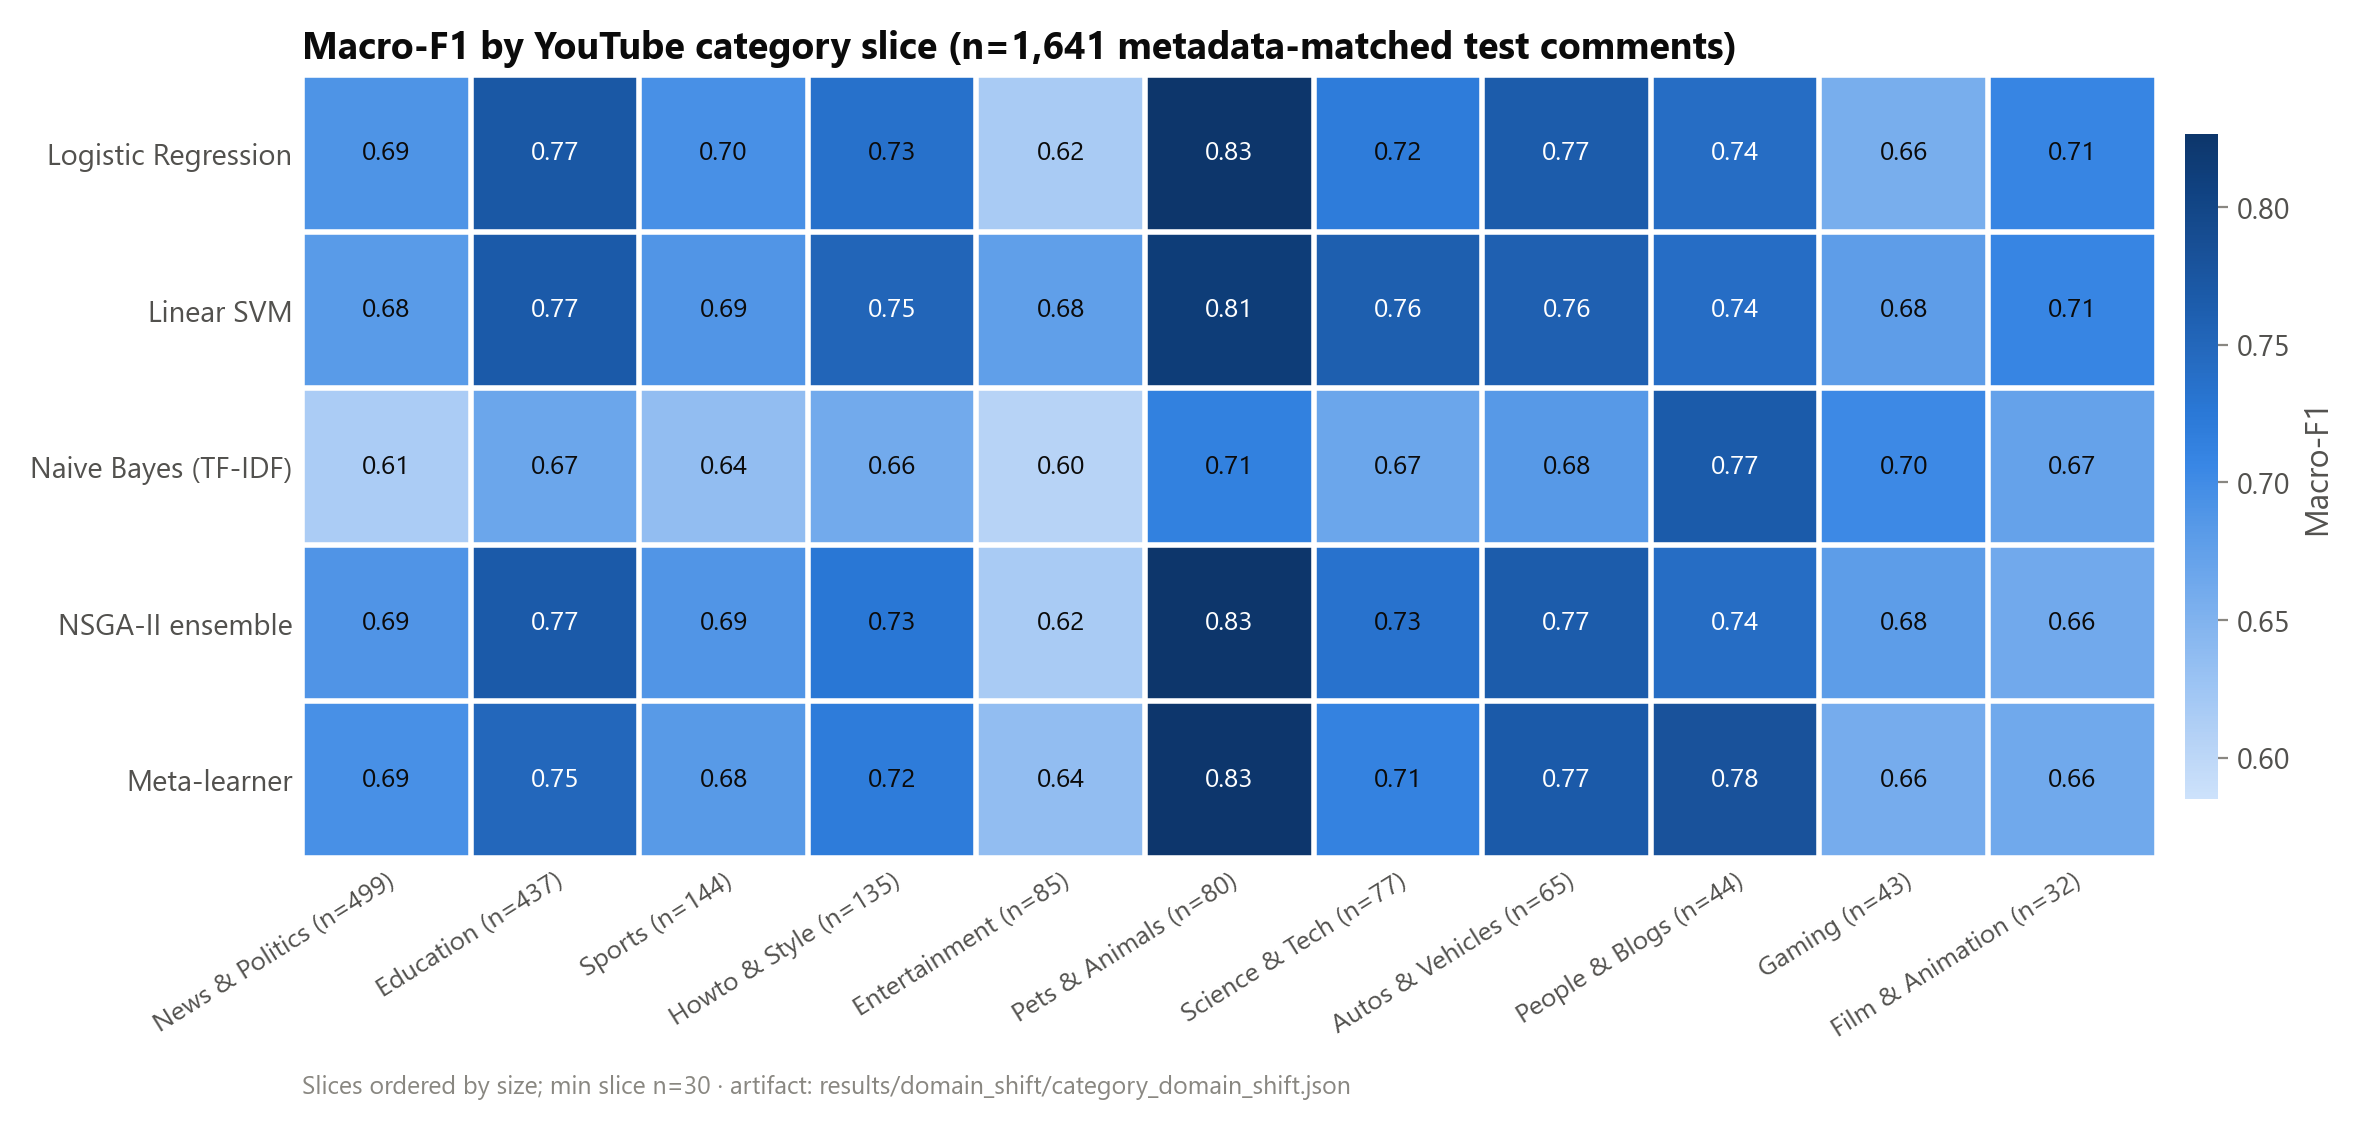

In [7]:
show_thesis_fig('fig_category_heatmap.png')

In [8]:
show_md('domain_shift/country_domain_shift.md')

# Domain-Shift / Robustness Slice Evaluation

- Created at: `2026-05-18T01:47:02Z`
- Dataset: `C:\Users\itsma\OneDrive\Documents\GitHub\Youtube_sentiment_analysis\backend\data\route_a_domain_10k\test.csv`
- Slice column: `CountryCode`
- Slice source: `metadata`
- Samples: `1641`

## Overall

| Model | Accuracy | Macro-F1 | Worst Slice | Worst Slice F1 | Spread |
| --- | ---: | ---: | --- | ---: | ---: |
| logreg | 0.736746 | 0.736832 | IE | 0.667823 | 0.114707 |
| svm | 0.736137 | 0.735756 | IE | 0.689130 | 0.075685 |
| tfidf | 0.678245 | 0.676433 | IN | 0.628792 | 0.094712 |
| ensemble_nsga2 | 0.735527 | 0.735490 | IE | 0.677481 | 0.095839 |
| meta_learner | 0.731261 | 0.732183 | IE | 0.664289 | 0.099956 |

## logreg Slices

| Slice | Samples | Accuracy | Macro-F1 |
| --- | ---: | ---: | ---: |
| IE | 109 | 0.678899 | 0.667823 |
| AU | 248 | 0.697581 | 0.695733 |
| GB | 193 | 0.720207 | 0.716402 |
| CA | 226 | 0.743363 | 0.730337 |
| US | 496 | 0.739919 | 0.740585 |
| DE | 83 | 0.759036 | 0.760361 |
| IN | 163 | 0.797546 | 0.774974 |
| NZ | 113 | 0.778761 | 0.782530 |

## svm Slices

| Slice | Samples | Accuracy | Macro-F1 |
| --- | ---: | ---: | ---: |
| IE | 109 | 0.697248 | 0.689130 |
| CA | 226 | 0.716814 | 0.698520 |
| AU | 248 | 0.725806 | 0.720179 |
| GB | 193 | 0.730570 | 0.727002 |
| US | 496 | 0.735887 | 0.736488 |
| DE | 83 | 0.734940 | 0.736497 |
| IN | 163 | 0.785276 | 0.763219 |
| NZ | 113 | 0.761062 | 0.764815 |

## tfidf Slices

| Slice | Samples | Accuracy | Macro-F1 |
| --- | ---: | ---: | ---: |
| IN | 163 | 0.674847 | 0.628792 |
| AU | 248 | 0.657258 | 0.650851 |
| GB | 193 | 0.668394 | 0.662602 |
| US | 496 | 0.667339 | 0.666818 |
| IE | 109 | 0.678899 | 0.669285 |
| CA | 226 | 0.707965 | 0.678084 |
| DE | 83 | 0.710843 | 0.719807 |
| NZ | 113 | 0.725664 | 0.723504 |

## ensemble_nsga2 Slices

| Slice | Samples | Accuracy | Macro-F1 |
| --- | ---: | ---: | ---: |
| IE | 109 | 0.688073 | 0.677481 |
| AU | 248 | 0.705645 | 0.703920 |
| GB | 193 | 0.715026 | 0.710237 |
| CA | 226 | 0.743363 | 0.726445 |
| US | 496 | 0.737903 | 0.738442 |
| IN | 163 | 0.785276 | 0.756694 |
| DE | 83 | 0.759036 | 0.760361 |
| NZ | 113 | 0.769912 | 0.773320 |

## meta_learner Slices

| Slice | Samples | Accuracy | Macro-F1 |
| --- | ---: | ---: | ---: |
| IE | 109 | 0.669725 | 0.664289 |
| AU | 248 | 0.697581 | 0.696491 |
| GB | 193 | 0.720207 | 0.718183 |
| IN | 163 | 0.760736 | 0.719130 |
| US | 496 | 0.733871 | 0.734810 |
| DE | 83 | 0.746988 | 0.747932 |
| CA | 226 | 0.761062 | 0.749744 |
| NZ | 113 | 0.761062 | 0.764245 |

## Interpretation

This is a metadata-backed domain-slice evaluation.


## 5.4 Generalisation to an independently human-labelled gold set

The gold set is annotated by two humans independently (see notebook 01, section 1.3) and held out from training. Comparing test-set performance to gold-set performance is direct evidence against overfitting to label noise. Source: `backend/results/gold_set/gold_set_evaluation.md`.

In [9]:
show_md('gold_set/gold_set_evaluation.md')

# Gold Set Evaluation (300 samples)

## Inter-Annotator Agreement

| Metric | Value |
| --- | --- |
| Percent agreement | 0.9700 |
| Krippendorff's Î± | 0.9547 |
| Fleiss' Îº | 0.9546 |
| Cohen's Îº (annotator_1 vs annotator_2) | 0.9546 |

*strong agreement (alpha >= 0.80)*

## Table 1: Model Performance vs Human-Reconciled Gold Labels

| Model | Accuracy | Macro F1 | Weighted F1 |
|-------|----------|----------|-------------|
| logreg | 0.6907 | 0.6940 | 0.6931 |
| svm | 0.6942 | 0.6978 | 0.6957 |
| tfidf | 0.7010 | 0.6988 | 0.6995 |
| ensemble_pso | 0.7045 | 0.7075 | 0.7067 |
| ensemble_nsga2 | 0.6976 | 0.7006 | 0.6999 |
| meta_learner | 0.6976 | 0.7001 | 0.7001 |

## Table 2: Model Performance vs Silver Labels (auto-annotated)

| Model | Accuracy | Macro F1 | Weighted F1 |
|-------|----------|----------|-------------|
| logreg | 0.9267 | 0.9273 | 0.9268 |
| svm | 0.9733 | 0.9737 | 0.9733 |
| tfidf | 0.7533 | 0.7529 | 0.7492 |
| ensemble_pso | 0.9267 | 0.9269 | 0.9267 |
| ensemble_nsga2 | 0.9267 | 0.9275 | 0.9268 |
| meta_learner | 0.9200 | 0.9192 | 0.9198 |

> **Note:** ensemble_pso scores 1.000 vs silver labels because it *is* the silver labeler (PSO-weighted ensemble). This is expected and does not indicate overfitting.

## Table 3: Per-Class F1 vs Human-Reconciled Gold Labels

| Model | Neg F1 | Neu F1 | Pos F1 | Macro F1 |
|-------|--------|--------|--------|----------|
| logreg | 0.6927 | 0.6168 | 0.7725 | 0.6940 |
| svm | 0.7086 | 0.6140 | 0.7708 | 0.6978 |
| tfidf | 0.6734 | 0.5946 | 0.8283 | 0.6988 |
| ensemble_pso | 0.7039 | 0.6291 | 0.7895 | 0.7075 |
| ensemble_nsga2 | 0.6966 | 0.6262 | 0.7789 | 0.7006 |
| meta_learner | 0.6901 | 0.6393 | 0.7708 | 0.7001 |

## Confusion Matrix: ensemble_pso vs Human-Reconciled Gold Labels

| True \ Pred | Negative | Neutral | Positive |
|-------------|----------|---------|----------|
| Negative | 63 | 13 | 3 |
| Neutral | 33 | 67 | 8 |
| Positive | 4 | 25 | 75 |

## Notes

- Human-reconciled gold labels used as primary reference (disputed items excluded: 9).

- Neutral class consistently has the lowest F1 across all models, consistent with inter-annotator difficulty on borderline comments.
- ensemble_pso (PSO-optimised weights, F1-best) and ensemble_nsga2 (NSGA-II knee-point, calibration-best) provide complementary trade-offs.


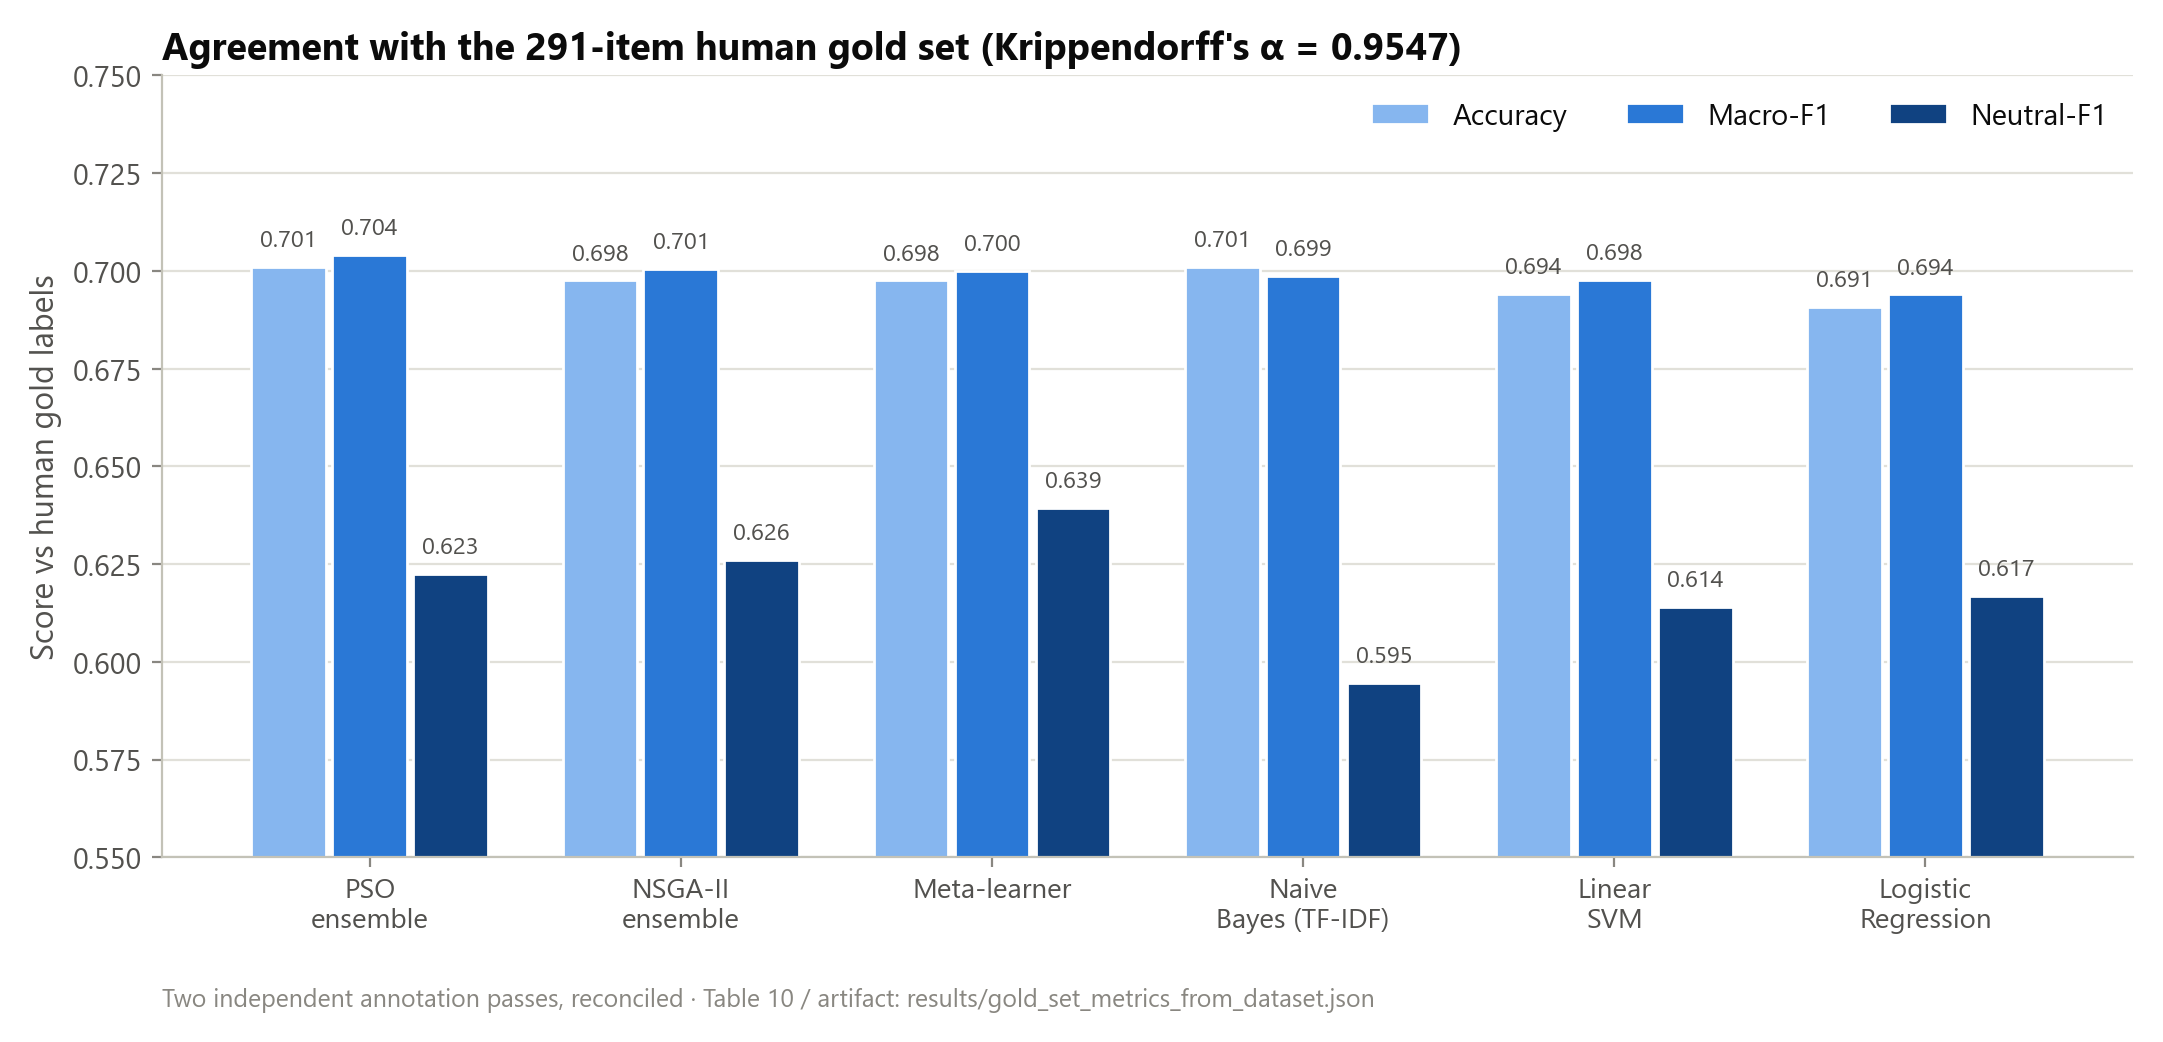

In [10]:
show_thesis_fig('fig_gold_set.png')

Held-out variant: `backend/results/gold_set/gold_set_evaluation_holdout.md`.

In [11]:
show_md('gold_set/gold_set_evaluation_holdout.md')

# Gold Set Evaluation, Held-Out-Only Subset

- Full gold set: 300 items (95 are exact-text members of the training split and excluded here; see `gold_set_train_membership.py`).
- Held-out subset (val + test + no-match): **205 items** (200 with a non-disputed human label).

## Model Performance vs Human-Reconciled Gold Labels (held-out subset)

| Model | Accuracy | Macro F1 | Weighted F1 | N |
|-------|----------|----------|-------------|---|
| logreg | 0.6950 | 0.6990 | 0.6968 | 200 |
| svm | 0.7050 | 0.7091 | 0.7067 | 200 |
| tfidf | 0.7050 | 0.7049 | 0.7027 | 200 |
| ensemble_pso | 0.7050 | 0.7088 | 0.7067 | 200 |
| ensemble_nsga2 | 0.7000 | 0.7039 | 0.7018 | 200 |
| meta_learner | 0.7000 | 0.7036 | 0.7017 | 200 |

> Compare against `results/gold_set/gold_set_evaluation.md` Table 1 (all 300 items, including 95 that overlap the training split). If accuracy/macro-F1 drop materially here, the full-gold-set figures were inflated by training-set memorisation.


## Notes / Limitations

*(Add your own framing here — this is the section examiners weight heavily. Suggested points to cover based on the artifacts above: (1) Neutral-class confusion as the dominant error mode, (2) any domain slices where macro-F1 drops noticeably, (3) the hybrid-DL negative result from notebook 03 and what it does/doesn't imply, (4) what the gold-set gap — if any — suggests about label-noise sensitivity.)*